In [24]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define paths
original_dataset_dir = 'image_datasets'  # Update this if necessary
base_dir = 'weed_Split'  # Directory to save splits
os.makedirs(base_dir, exist_ok=True)

# Create subdirectories for train, validation, and test datasets
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Split each class into train, val, and test sets
for class_name in os.listdir(original_dataset_dir):
    class_path = os.path.join(original_dataset_dir, class_name)
    if os.path.isdir(class_path):
        os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(val_dir, class_name), exist_ok=True)
        os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

        files = os.listdir(class_path)
        train_files, temp_files = train_test_split(files, test_size=0.2, random_state=42)
        val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

        # Move files
        for file in train_files:
            shutil.copy(os.path.join(class_path, file), os.path.join(train_dir, class_name, file))
        for file in val_files:
            shutil.copy(os.path.join(class_path, file), os.path.join(val_dir, class_name, file))
        for file in test_files:
            shutil.copy(os.path.join(class_path, file), os.path.join(test_dir, class_name, file))

print("Dataset successfully split into Train, Validation, and Test sets.")


Dataset successfully split into Train, Validation, and Test sets.


In [61]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Only normalization for validation and test
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Define a higher target size for better resolution
target_size = (224, 224)  # You can increase to 299x299 or other sizes based on your model

# Create data generators with the higher resolution
train_generator = train_datagen.flow_from_directory(
    'weed_Split/train',  # Update path if necessary
    target_size=target_size,
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    'weed_Split/val',
    target_size=target_size,
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    'weed_Split/test',
    target_size=target_size,
    batch_size=32,
    class_mode='categorical',
    shuffle=False  # Important for confusion matrix
)

# Output to check
print(f"Train Samples: {train_generator.samples}")
print(f"Validation Samples: {val_generator.samples}")
print(f"Classes: {train_generator.class_indices}")



Found 6416 images belonging to 11 classes.
Found 802 images belonging to 11 classes.
Found 809 images belonging to 11 classes.
Train Samples: 6416
Validation Samples: 802
Classes: {'Alternanthera philoxeroide': 0, 'Centella asiatica': 1, 'Commelina benghalensis': 2, 'Cyperus ochraceus': 3, 'Fimbristylis littoralis': 4, 'Ipomoea aquatic': 5, 'Marsilea minuta': 6, 'Panicum repens': 7, 'Paspalum scrobiculatum': 8, 'Pteris vittata': 9, 'Synedrella nodiflora': 10}


In [62]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

# Define the model
model = Sequential([
    Input(shape=(224, 224, 3)),  # Explicitly define the input shape to match the target size (224x224)
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(len(train_generator.class_indices), activation='softmax')  # Output layer based on number of classes
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Define Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Now the model is ready for training with the updated image resolution.


In [63]:
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    validation_data=val_generator,
    validation_steps=len(val_generator),
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.2355 - loss: 2.7762 - val_accuracy: 0.4177 - val_loss: 1.7553
Epoch 2/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.4652 - loss: 1.5678 - val_accuracy: 0.6147 - val_loss: 1.1997
Epoch 3/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.5714 - loss: 1.2817 - val_accuracy: 0.6895 - val_loss: 0.9779
Epoch 4/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.6486 - loss: 1.0422 - val_accuracy: 0.7045 - val_loss: 0.9260
Epoch 5/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 216s 1s/step - accuracy: 0.6955 - loss: 0.8870 - val_accuracy: 0.7556 - val_loss: 0.8077
Epoch 6/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.7260 - loss: 0.7982 - val_accuracy: 0.7706 - val_loss: 0.7268
Epoch 7/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.7397 - loss: 0.7960 - val_accuracy: 0.7756 - val_loss: 0.6395
Epoch 8/30
201/201 ━━━━━━━━━━━━━━━━━━━━ 215s 1s/step - accuracy: 0.7551 - loss: 0.7149 - val_accu

In [68]:
 pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


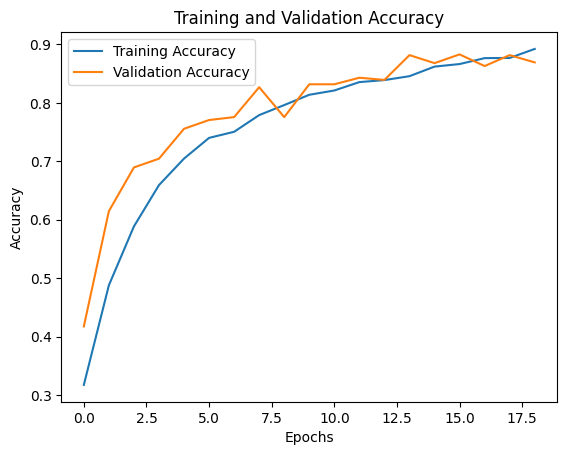

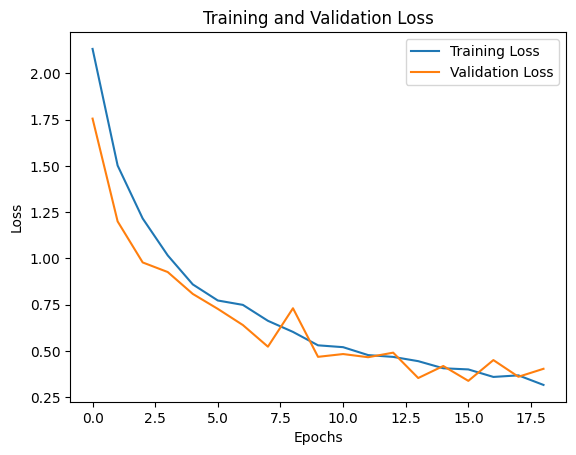

In [70]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [71]:
model.save("weeds.h5")

Found 809 images belonging to 11 classes.


26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 240ms/step


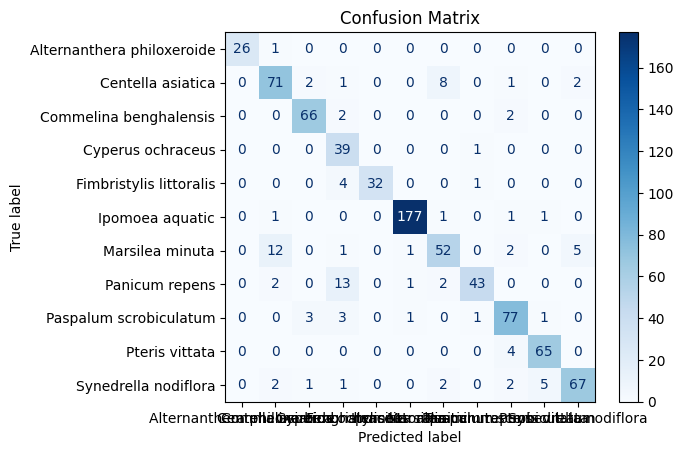

                            precision    recall  f1-score   support

Alternanthera philoxeroide       1.00      0.96      0.98        27
         Centella asiatica       0.80      0.84      0.82        85
    Commelina benghalensis       0.92      0.94      0.93        70
         Cyperus ochraceus       0.61      0.97      0.75        40
   Fimbristylis littoralis       1.00      0.86      0.93        37
           Ipomoea aquatic       0.98      0.98      0.98       181
           Marsilea minuta       0.80      0.71      0.75        73
            Panicum repens       0.93      0.70      0.80        61
    Paspalum scrobiculatum       0.87      0.90      0.88        86
            Pteris vittata       0.90      0.94      0.92        69
      Synedrella nodiflora       0.91      0.84      0.87        80

                  accuracy                           0.88       809
                 macro avg       0.88      0.88      0.87       809
              weighted avg       0.89      0.8

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


model = load_model("weeds.h5")


test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    'weed_Split/test', 
    target_size=(224, 224),  
    batch_size=32,
    class_mode='categorical',
    shuffle=False  
)

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1) 
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys()) 


cm = confusion_matrix(true_classes, predicted_classes)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)


In [75]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator


model = load_model("weeds.h5")


test_datagen = ImageDataGenerator(rescale=1./255)


test_generator = test_datagen.flow_from_directory(
    'weed_Split/test', 
    target_size=(224, 224),  
    batch_size=32,
    class_mode='categorical',
    shuffle=False 
)


test_loss, test_accuracy = model.evaluate(test_generator)


print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


Found 809 images belonging to 11 classes.


C:\Users\User\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 221ms/step - accuracy: 0.8983 - loss: 0.2852
Test Accuracy: 88.38%
Test Loss: 0.3254


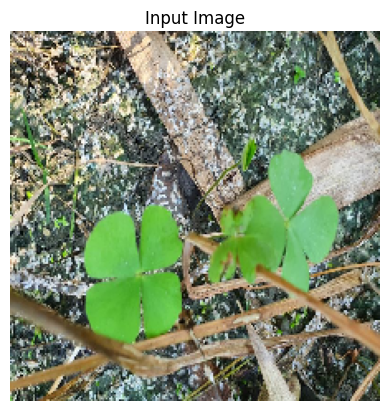

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step

Class Probabilities:
Alternanthera philoxeroide: 0.00%
Centella asiatica: 0.07%
Commelina benghalensis: 0.00%
Cyperus ochraceus: 0.00%
Fimbristylis littoralis: 0.00%
Ipomoea aquatic: 0.00%
Marsilea minuta: 99.89%
Panicum repens: 0.00%
Paspalum scrobiculatum: 0.00%
Pteris vittata: 0.00%
Synedrella nodiflora: 0.05%

Predicted Class: Marsilea minuta
Confidence: 99.89%


In [1]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load the trained model
model = load_model("weeds.h5")

# Path to the image to predict
image_path = 'weed_Split/test/Marsilea minuta/7_20221126_0045.jpg'  # Replace with the actual image path

# Preprocess the image
img = image.load_img(image_path, target_size=(224, 224))  # Ensure it matches training input size
plt.imshow(img)
plt.axis('off')
plt.title('Input Image')
plt.show()

# Convert the image to an array
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
img_array = img_array / 255.0  # Normalize the image

# Make predictions
predictions = model.predict(img_array)[0]  # Remove batch dimension to make it a 1D array

# Get class labels from the model
class_labels = ['Alternanthera philoxeroide', 'Centella asiatica', 'Commelina benghalensis', 'Cyperus ochraceus', 
                'Fimbristylis littoralis', 'Ipomoea aquatic', 'Marsilea minuta', 'Panicum repens','Paspalum scrobiculatum','Pteris vittata','Synedrella nodiflora']  # Update with your actual class labels

# Display predictions for all classes
print("\nClass Probabilities:")
for i, label in enumerate(class_labels):
    print(f"{label}: {predictions[i] * 100:.2f}%")

# Find the class with the highest probability
predicted_class_index = np.argmax(predictions)  # Get the class index with the highest probability
predicted_class = class_labels[predicted_class_index]
confidence = predictions[predicted_class_index] * 100  # Confidence as a percentage

# Output the top prediction
print(f"\nPredicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")